In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import List, Tuple, Optional, Iterable

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('with_comfort.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)


In [2]:
class CNNLSTMWithFuture(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, cnn_out_channels=32, kernel_size=3):
        super().__init__()
        # self.norm = nn.LayerNorm(input_size) # Add normalization layer before Conv1D
        self.conv1d = nn.Conv1d(
            in_channels=input_size, 
            out_channels=cnn_out_channels, 
            kernel_size=kernel_size, 
            padding=kernel_size // 2
        )
        self.relu = nn.ReLU()
        
        self.lstm = nn.LSTM(
            input_size=cnn_out_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=0.15,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x_seq):  
        # x_seq = self.norm(x_seq)
        x_seq = x_seq.permute(0, 2, 1) 
        x_seq = self.relu(self.conv1d(x_seq))  
        x_seq = x_seq.permute(0, 2, 1) 
        
        # LSTM + output
        _, (hn, _) = self.lstm(x_seq)
        return self.fc(hn[-1]).squeeze(-1)
    
def ensure_columns(df: pd.DataFrame) -> pd.DataFrame:
    df['RH_lag1'] = df['RH'].shift(1)
    df['RH_lag2'] = df['RH'].shift(2)
    df['RH_lag3'] = df['RH'].shift(3)
    df['RH_lag4'] = df['RH'].shift(4)
    df['RH_target'] = df['RH'].shift(-1)
    df.fillna(method='bfill', inplace=True)
    return df


def make_splits_by_is_test_or_date(
    df: pd.DataFrame,
    val_start_str: str = "2023-01-22",
    val_days: int = 14,
    test_days: int = 14,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

    if not isinstance(df.index, pd.DatetimeIndex):
        if "timestamps" in df.columns:
            df = df.copy()
            df["timestamps"] = pd.to_datetime(df["timestamps"])
            df = df.set_index("timestamps")
        else:
            raise ValueError("DataFrame must have a DateTimeIndex or a 'timestamps' column.")

    # Define windows
    val_start = pd.Timestamp(val_start_str)
    val_end   = val_start + pd.Timedelta(days=val_days)
    test_start = val_end
    test_end   = test_start + pd.Timedelta(days=test_days)

    # Build masks (inclusive start, exclusive end)
    idx = np.arange(len(df))
    ts = df.index

    val_mask  = (ts >= val_start) & (ts < val_end)
    test_mask = (ts >= test_start) & (ts < test_end)

    # Ensure they are disjoint
    overlap = val_mask & test_mask
    if overlap.any():
        raise RuntimeError("Validation and test windows overlap; check the inputs.")

    train_mask = ~(val_mask | test_mask)

    train_idx = idx[train_mask]
    val_idx   = idx[val_mask]
    test_idx  = idx[test_mask]

    return train_idx, val_idx, test_idx

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
    
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0

def _time_axis(ax):
    loc = AutoDateLocator()
    fmt = ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    ax.grid(True, which="major")
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)

import random

def train_lstm_model(df, input_cols, target_col='RH_target', window_size=6, batch_size=64, use_scaler=True, epochs=20, hidden_size=128, num_layers=3, lr=0.001, save_dir=None, device: str = "cuda" if torch.cuda.is_available() else "cpu", df_index=None):
    scaler = None
    df_proc = df.copy()
    os.makedirs(save_dir, exist_ok=True)


    class RHForecastDataset(Dataset):
        def __init__(self, df, input_cols, target_col, window_size):
            self.df = df.reset_index(drop=True)
            self.input_cols = input_cols
            self.target_col = target_col
            self.window_size = window_size

        def __len__(self):
            return len(self.df) - self.window_size

        def __getitem__(self, idx):
            x = self.df.loc[idx:idx + self.window_size - 1, self.input_cols].values.astype(np.float32)
            y = self.df.loc[idx + self.window_size, self.target_col]
            return torch.tensor(x), torch.tensor(y, dtype=torch.float32)
        

    scaler = StandardScaler()
    scaling_cols = [col for col in input_cols if not (col.startswith('hour_') or col.startswith('RH') or col.startswith('month'))]
    print(f"Scaling columns: {scaling_cols}")

    df_scaled = df_proc.copy()
    if target_col in df_scaled.columns:
        input_cols = [col for col in input_cols if col != target_col]
    df_scaled[scaling_cols] = scaler.fit_transform(df_scaled[scaling_cols])

    train_idx, val_idx, test_idx = make_splits_by_is_test_or_date(df_scaled)
    df_train = df_scaled.iloc[train_idx]
    df_val   = df_scaled.iloc[val_idx]
    df_test  = df_scaled.iloc[test_idx]

    ds_train = RHForecastDataset(df_train, input_cols, target_col, window_size)
    ds_val   = RHForecastDataset(df_val, input_cols, target_col, window_size)
    ds_test   = RHForecastDataset(df_test, input_cols, target_col, window_size)

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_val   = DataLoader(ds_val, batch_size=batch_size, shuffle=False)
    dl_test   = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

    model = CNNLSTMWithFuture(input_size=len(input_cols), hidden_size=hidden_size, num_layers=num_layers,
                                  cnn_out_channels=32, kernel_size=3).to(device)
    ckpt_name = f"best_rh.pt"   

    ckpt_path = os.path.join(save_dir, ckpt_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_val_loss = float('inf') 

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb_seq, yb in dl_train:
            xb_seq, yb = xb_seq.to(device), yb.to(device)
            pred = model(xb_seq).squeeze()
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb_seq, yb in dl_val:
                xb_seq, yb = xb_seq.to(device), yb.to(device)
                if random.random() < 0.1:
                    xb_seq_clone = xb_seq.clone()
                    preds_seq = model(xb_seq_clone).detach()
                    xb_seq_clone[:, -1, 0] = preds_seq 
                    pred = model(xb_seq_clone).squeeze()
                else:
                    pred = model(xb_seq).squeeze()
                # pred = model(xb_seq).squeeze()
                loss = loss_fn(pred, yb)
                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        print(f"[{epoch+1:02d}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
        # if avg_loss < best_train_loss:
        #     best_train_loss = avg_loss
        #     torch.save(model.state_dict(), ckpt_path)
        #     print(f"✅ Saved best model at epoch {epoch+1} → {ckpt_path}")

    if ckpt_path:
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
        torch.save(best_model_state, ckpt_path)
        print(f"✅ Saved best RH model to {ckpt_path}")

    if df_index is not None:
        scaler_path = f"models/scalers/df_{df_index}"
        scaler_save = os.path.join(scaler_path, "scaler_rh.pkl")
        joblib.dump(scaler, scaler_save)
        print(f"✅ Saved RH scaler to {scaler_save}")

    model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
    
    model.eval()

    test_timestamps = [df_proc.iloc[i].name for i in test_idx]

    preds, actuals, times = [], [], []

    with torch.no_grad():
        batch_start = 0
        for xb_seq, yb in dl_test:
            xb_seq, yb = xb_seq.to(device), yb.to(device)
            out = model(xb_seq)
            preds.extend(out.cpu().numpy())
            actuals.extend(yb.cpu().numpy())

            batch_size = len(xb_seq)
            times.extend(test_timestamps[batch_start:batch_start + batch_size])
            batch_start += batch_size

    rmse = root_mean_squared_error(actuals, preds)
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    smp = smape(actuals, preds)
    
    metrics_df = pd.DataFrame(
        {
            "Metric": ["RMSE", "MAE", "R²", "sMAPE (%)"],
            "Value":  [rmse,  mae,   r2,   smp]
        }
    )
    metrics_df["Value"] = metrics_df["Value"].map(lambda v: f"{v:,.4f}")
    print("\n" + "="*47)
    print(" Performance Metrics".center(47, " "))
    print("="*47)
    print(metrics_df.to_string(index=False))
    print("="*47 + "\n")

    target_col_true = target_col + '_true'
    target_col_pred = target_col + '_pred'      
    results = pd.DataFrame(
        {target_col_true: actuals, target_col_pred: preds},
        index=pd.to_datetime(times)
    ).sort_index()
    plt.rcParams.update({
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "font.size": 11,
    })

    ylabel = "Indoor Temperature [°C]" if target_col == "Tin_target" else "RH (%)"


    N_skip = 6
    N_plot = 96
    plot_results = results.iloc[N_skip:N_skip + N_plot]

    fig, ax = plt.subplots(figsize=(12.5, 4.8))
    ax.plot(plot_results.index, plot_results[target_col_true], linewidth=2.0, label="True")
    ax.plot(plot_results.index, plot_results[target_col_pred], linewidth=2.0, linestyle="--", label="Predicted")

    # annotate metrics in subtitle
    ax.set_title(
        f"Test Segment — {N_plot} points (skip {N_skip})\n"
        f"RMSE={rmse:.3f} • MAE={mae:.3f} • R²={r2:.3f} • sMAPE={smp:.2f}%",
        pad=12
    )
    ax.set_ylabel(ylabel)
    _time_axis(ax)

    # move legend outside for clarity
    leg = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    for line in leg.get_lines():
        line.set_linewidth(3)

    fig.tight_layout()
    plt.show()

    # -------------------------------
    # (2) Parity Plot (Prediction vs Truth)
    # -------------------------------
    # fig, ax = plt.subplots(figsize=(5.6, 5.6))
    # ax.scatter(results[target_col_true], results[target_col_pred], s=12, alpha=0.6)
    # mn = np.nanmin([results[target_col_true].min(), results[target_col_pred].min()])
    # mx = np.nanmax([results[target_col_true].max(), results[target_col_pred].max()])
    # ax.plot([mn, mx], [mn, mx], linestyle="-", linewidth=2.0)
    # ax.set_xlabel("True")
    # ax.set_ylabel("Predicted")
    # ax.set_title("Parity Plot (y = x)")
    # ax.set_aspect("equal", adjustable="box")
    # ax.minorticks_on()
    # fig.tight_layout()
    # plt.show()

    # -------------------------------
    # (3) Residuals vs Time
    # -------------------------------
    # residuals = results[target_col_pred] - results[target_col_true]
    # fig, ax = plt.subplots(figsize=(12.5, 3.6))
    # ax.plot(results.index, residuals, linewidth=1.5)
    # ax.axhline(0.0, linewidth=1.0)
    # ax.set_title(
    #     f"Residuals (Pred - True) — mean={residuals.mean():.3f}, std={residuals.std():.3f}"
    # )
    # ax.set_ylabel("Residual")
    # _time_axis(ax)
    # fig.tight_layout()
    # plt.show()
    return model, scaler



======= House 0 =========
Scaling columns: ['Tout', 'hvac_mode']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17092\500686914.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


[01] Train Loss: 1218.2999 | Val Loss: 203.2473
[02] Train Loss: 628.2071 | Val Loss: 46.6330
[03] Train Loss: 367.2949 | Val Loss: 34.3234
[04] Train Loss: 255.6450 | Val Loss: 74.8563
[05] Train Loss: 215.8788 | Val Loss: 118.6889
[06] Train Loss: 204.6538 | Val Loss: 147.5642
[07] Train Loss: 166.1656 | Val Loss: 5.5205
[08] Train Loss: 89.5113 | Val Loss: 3.4504
[09] Train Loss: 57.3624 | Val Loss: 3.1203
[10] Train Loss: 38.1636 | Val Loss: 6.1825
[11] Train Loss: 26.5999 | Val Loss: 3.0068
[12] Train Loss: 18.9492 | Val Loss: 3.3607
[13] Train Loss: 14.2936 | Val Loss: 1.8947
[14] Train Loss: 10.8408 | Val Loss: 2.3655
[15] Train Loss: 8.5997 | Val Loss: 1.7781
[16] Train Loss: 6.9318 | Val Loss: 1.6318
[17] Train Loss: 5.8277 | Val Loss: 1.6107
[18] Train Loss: 4.8299 | Val Loss: 1.8470
[19] Train Loss: 4.1819 | Val Loss: 1.5473
[20] Train Loss: 3.6209 | Val Loss: 2.2491
[21] Train Loss: 3.3426 | Val Loss: 1.7964
[22] Train Loss: 2.8977 | Val Loss: 1.4845
[23] Train Loss: 2.6897

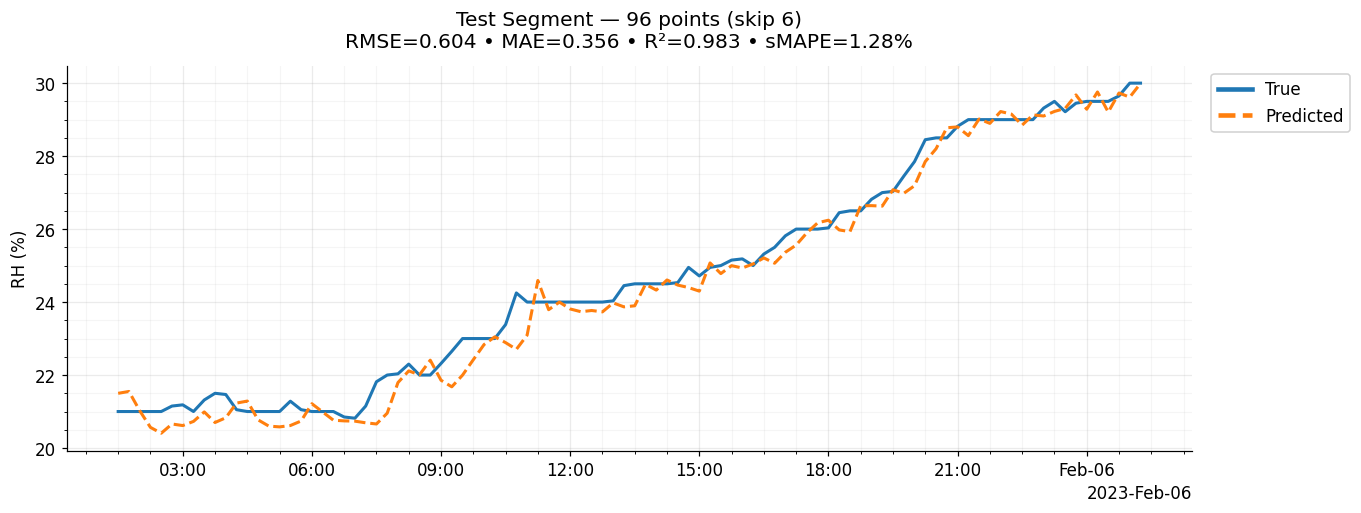

======= House 1 =========
Scaling columns: ['Tout', 'hvac_mode']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17092\500686914.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


[01] Train Loss: 1002.3437 | Val Loss: 85.9153
[02] Train Loss: 519.4733 | Val Loss: 27.8596
[03] Train Loss: 324.1591 | Val Loss: 74.4446
[04] Train Loss: 254.6677 | Val Loss: 136.6754
[05] Train Loss: 229.7505 | Val Loss: 143.6449
[06] Train Loss: 138.3101 | Val Loss: 2.8099
[07] Train Loss: 85.6059 | Val Loss: 2.3612
[08] Train Loss: 56.0433 | Val Loss: 2.3578
[09] Train Loss: 37.8694 | Val Loss: 2.3115
[10] Train Loss: 26.0794 | Val Loss: 2.1075
[11] Train Loss: 18.5819 | Val Loss: 1.8622
[12] Train Loss: 13.5893 | Val Loss: 2.1518
[13] Train Loss: 10.3297 | Val Loss: 1.6735
[14] Train Loss: 8.0784 | Val Loss: 2.1858
[15] Train Loss: 6.2508 | Val Loss: 1.6170
[16] Train Loss: 5.0810 | Val Loss: 1.5438
[17] Train Loss: 4.2163 | Val Loss: 1.4062
[18] Train Loss: 3.6599 | Val Loss: 1.8514
[19] Train Loss: 3.1329 | Val Loss: 1.5514
[20] Train Loss: 2.6659 | Val Loss: 1.3623
[21] Train Loss: 2.5328 | Val Loss: 1.4653
[22] Train Loss: 2.3119 | Val Loss: 1.4786
[23] Train Loss: 2.1310 | V

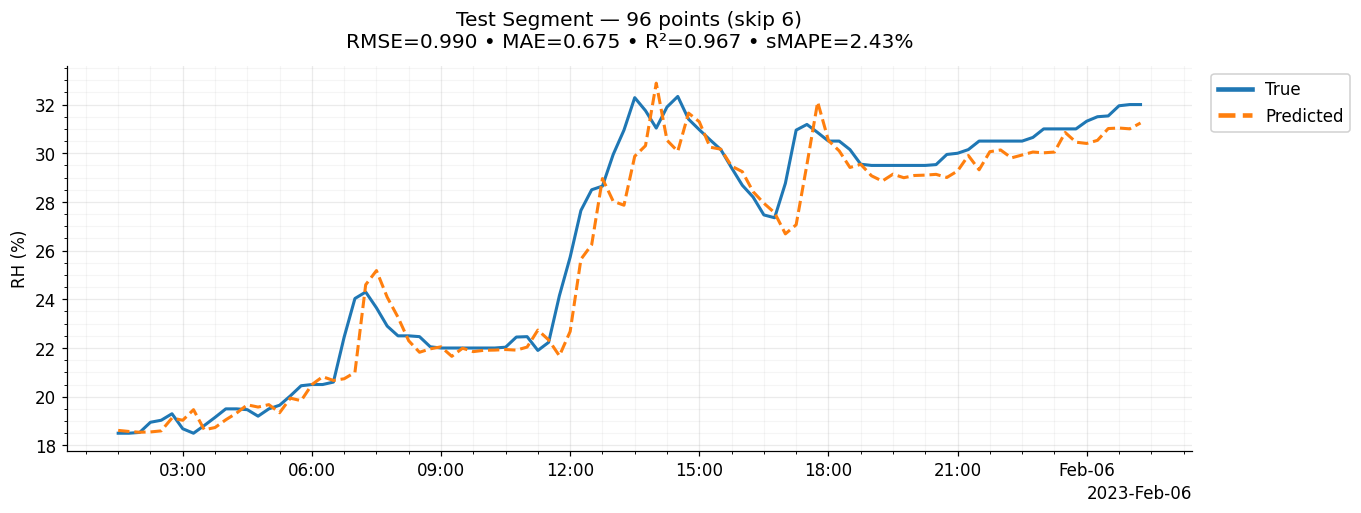

======= House 2 =========
Scaling columns: ['Tout', 'hvac_mode']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17092\500686914.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


[01] Train Loss: 1412.0061 | Val Loss: 326.3241
[02] Train Loss: 735.3916 | Val Loss: 92.5449
[03] Train Loss: 413.5327 | Val Loss: 30.2496
[04] Train Loss: 260.3779 | Val Loss: 46.8445
[05] Train Loss: 198.3351 | Val Loss: 85.3549
[06] Train Loss: 177.1733 | Val Loss: 118.1845
[07] Train Loss: 155.1379 | Val Loss: 5.8771
[08] Train Loss: 82.3541 | Val Loss: 2.3062
[09] Train Loss: 52.7433 | Val Loss: 1.9563
[10] Train Loss: 35.8810 | Val Loss: 2.6477
[11] Train Loss: 25.4033 | Val Loss: 2.2821
[12] Train Loss: 18.5117 | Val Loss: 1.5452
[13] Train Loss: 14.1727 | Val Loss: 1.7752
[14] Train Loss: 11.0398 | Val Loss: 1.5323
[15] Train Loss: 8.7947 | Val Loss: 1.5821
[16] Train Loss: 7.0337 | Val Loss: 1.4385
[17] Train Loss: 6.0642 | Val Loss: 1.3686
[18] Train Loss: 4.8100 | Val Loss: 2.5775
[19] Train Loss: 4.1961 | Val Loss: 1.3526
[20] Train Loss: 3.5458 | Val Loss: 1.6675
[21] Train Loss: 3.2177 | Val Loss: 1.4507
[22] Train Loss: 2.7593 | Val Loss: 1.4658
[23] Train Loss: 2.4548 

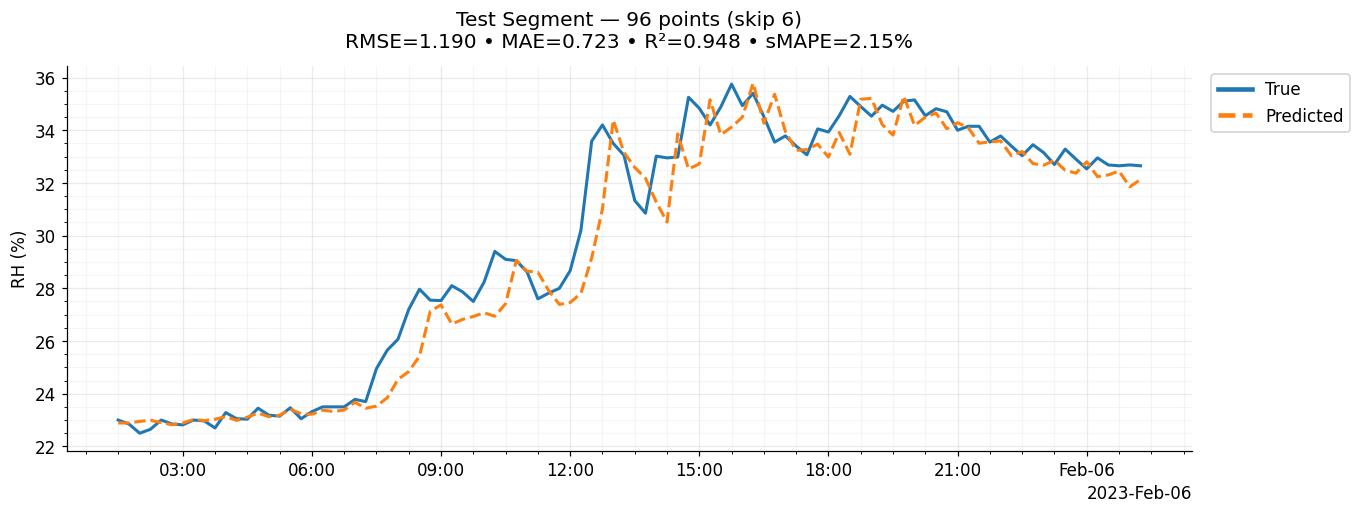

======= House 3 =========
Scaling columns: ['Tout', 'hvac_mode']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17092\500686914.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


[01] Train Loss: 1001.4754 | Val Loss: 75.6821
[02] Train Loss: 526.6053 | Val Loss: 23.9352
[03] Train Loss: 341.8123 | Val Loss: 71.2913
[04] Train Loss: 277.1433 | Val Loss: 132.0505
[05] Train Loss: 244.3832 | Val Loss: 3.3171
[06] Train Loss: 139.3926 | Val Loss: 1.1055
[07] Train Loss: 88.8972 | Val Loss: 0.9962
[08] Train Loss: 57.9651 | Val Loss: 0.7109
[09] Train Loss: 38.9937 | Val Loss: 0.9368
[10] Train Loss: 26.4869 | Val Loss: 0.7555
[11] Train Loss: 18.5021 | Val Loss: 0.7259
[12] Train Loss: 13.0569 | Val Loss: 0.6254
[13] Train Loss: 9.3133 | Val Loss: 0.5499
[14] Train Loss: 6.7965 | Val Loss: 0.8371
[15] Train Loss: 5.0461 | Val Loss: 0.4921
[16] Train Loss: 3.7931 | Val Loss: 0.5038
[17] Train Loss: 3.0525 | Val Loss: 0.7284
[18] Train Loss: 2.3900 | Val Loss: 0.4664
[19] Train Loss: 1.8408 | Val Loss: 0.5876
[20] Train Loss: 1.6041 | Val Loss: 0.6699
[21] Train Loss: 1.3394 | Val Loss: 0.5002
[22] Train Loss: 1.1287 | Val Loss: 0.4800
[23] Train Loss: 1.0403 | Val 

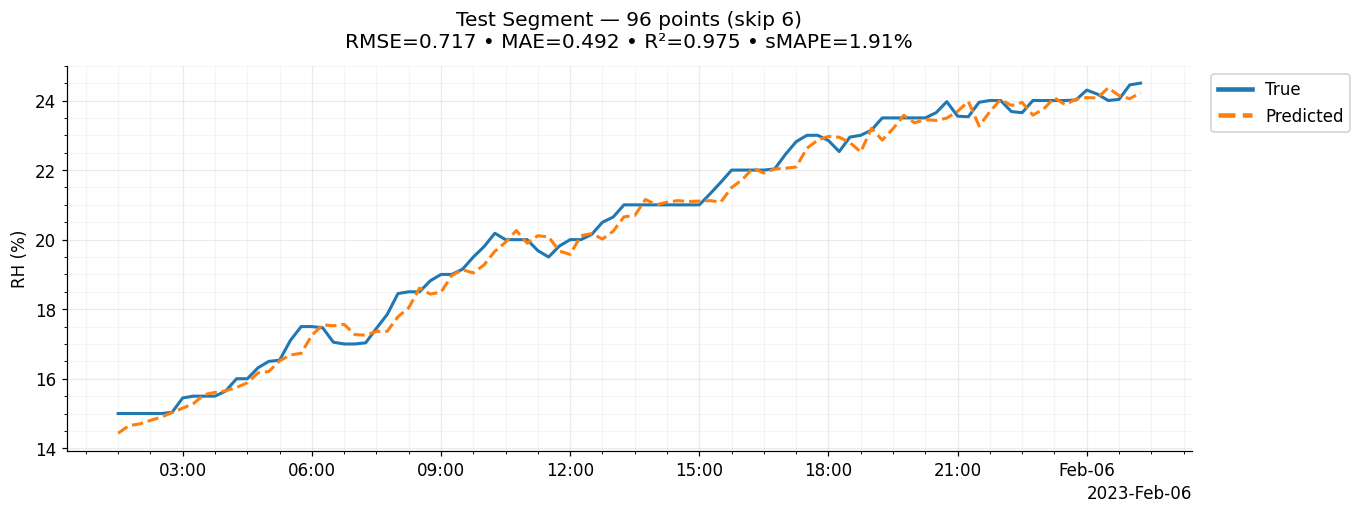

======= House 4 =========
Scaling columns: ['Tout', 'hvac_mode']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17092\500686914.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


[01] Train Loss: 1204.4757 | Val Loss: 63.8646
[02] Train Loss: 638.4853 | Val Loss: 19.0810
[03] Train Loss: 392.3230 | Val Loss: 74.7436
[04] Train Loss: 257.7672 | Val Loss: 0.8165
[05] Train Loss: 163.1631 | Val Loss: 0.4247
[06] Train Loss: 105.0380 | Val Loss: 0.3112
[07] Train Loss: 67.6378 | Val Loss: 0.2996
[08] Train Loss: 44.4833 | Val Loss: 0.5485
[09] Train Loss: 30.0737 | Val Loss: 0.3085
[10] Train Loss: 21.1642 | Val Loss: 0.7169
[11] Train Loss: 15.1987 | Val Loss: 1.2542
[12] Train Loss: 11.5462 | Val Loss: 0.3234
[13] Train Loss: 8.7295 | Val Loss: 0.4066
[14] Train Loss: 6.9158 | Val Loss: 0.2695
[15] Train Loss: 5.7303 | Val Loss: 0.2922
[16] Train Loss: 4.6782 | Val Loss: 0.2877
[17] Train Loss: 4.1034 | Val Loss: 0.4082
[18] Train Loss: 3.6104 | Val Loss: 0.2168
[19] Train Loss: 2.9542 | Val Loss: 0.4623
[20] Train Loss: 2.6393 | Val Loss: 0.3524
[21] Train Loss: 2.4098 | Val Loss: 0.7081
[22] Train Loss: 2.1193 | Val Loss: 0.2125
[23] Train Loss: 1.9684 | Val Lo

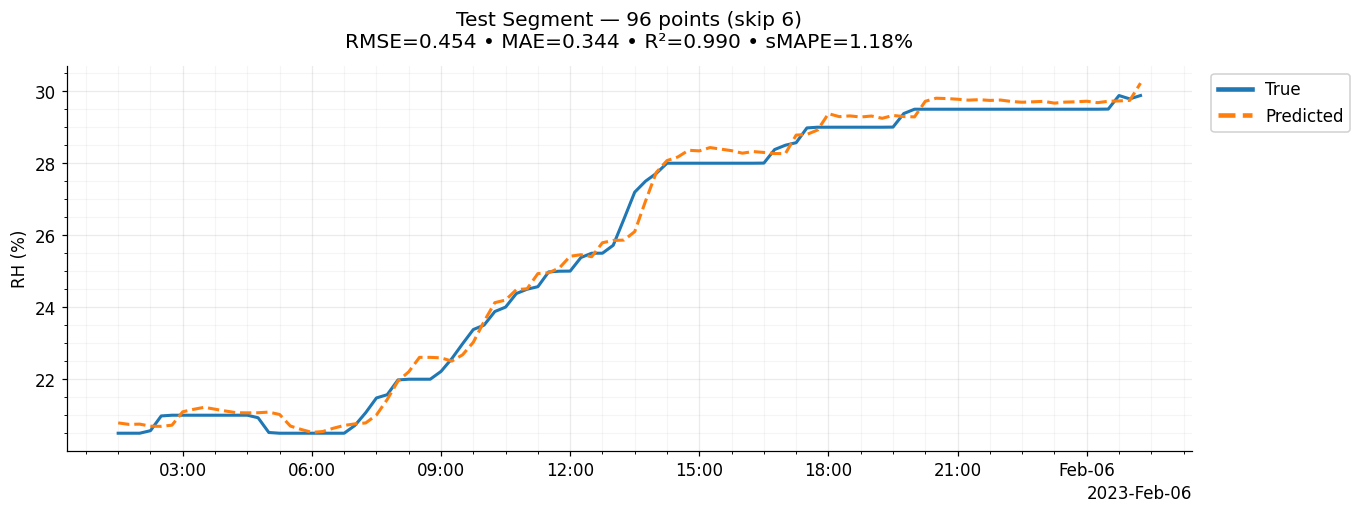

======= House 5 =========
Scaling columns: ['Tout', 'hvac_mode']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17092\500686914.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


[01] Train Loss: 1089.3374 | Val Loss: 100.5616
[02] Train Loss: 570.6992 | Val Loss: 29.3441
[03] Train Loss: 352.8936 | Val Loss: 70.1032
[04] Train Loss: 239.5719 | Val Loss: 1.3481
[05] Train Loss: 149.3372 | Val Loss: 0.8211
[06] Train Loss: 97.0076 | Val Loss: 1.0319
[07] Train Loss: 64.1019 | Val Loss: 0.7537
[08] Train Loss: 43.2430 | Val Loss: 0.7043
[09] Train Loss: 29.5089 | Val Loss: 0.8926
[10] Train Loss: 20.5667 | Val Loss: 0.8338
[11] Train Loss: 14.8583 | Val Loss: 0.5561
[12] Train Loss: 11.0525 | Val Loss: 0.7069
[13] Train Loss: 8.4572 | Val Loss: 0.5876
[14] Train Loss: 6.5783 | Val Loss: 0.7241
[15] Train Loss: 5.3758 | Val Loss: 0.6013
[16] Train Loss: 4.3039 | Val Loss: 0.4752
[17] Train Loss: 3.5714 | Val Loss: 0.5172
[18] Train Loss: 2.9890 | Val Loss: 0.5833
[19] Train Loss: 2.5269 | Val Loss: 0.4645
[20] Train Loss: 2.2620 | Val Loss: 0.5400
[21] Train Loss: 1.9531 | Val Loss: 0.7762
[22] Train Loss: 1.7227 | Val Loss: 0.5392
[23] Train Loss: 1.4906 | Val Lo

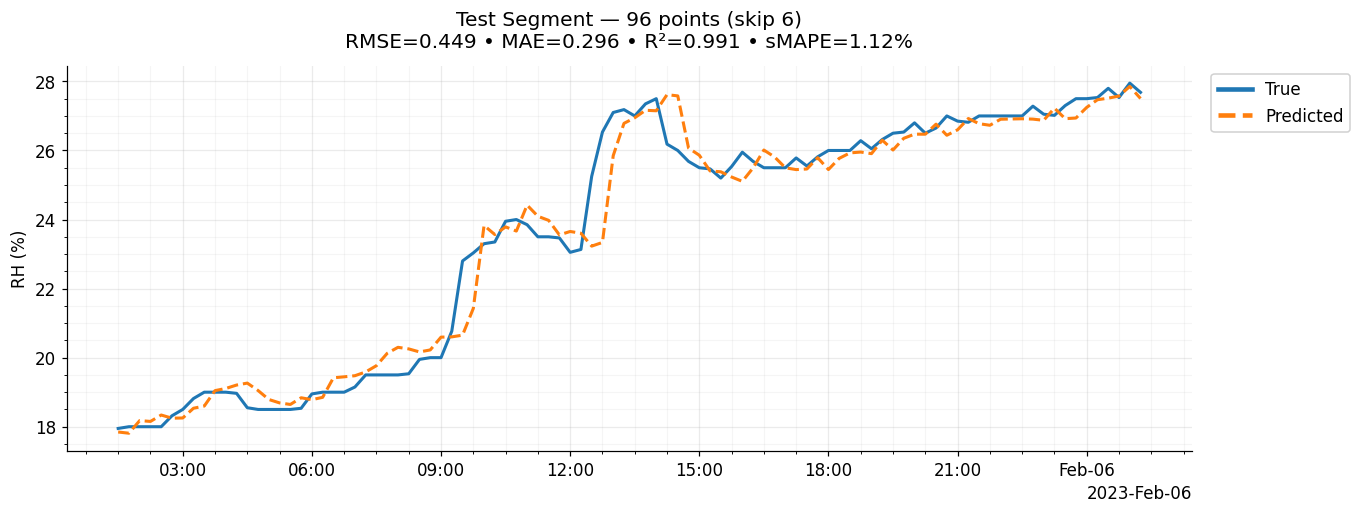

======= House 6 =========
Scaling columns: ['Tout', 'hvac_mode']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17092\500686914.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


[01] Train Loss: 1266.9387 | Val Loss: 100.8376
[02] Train Loss: 690.5123 | Val Loss: 29.4706
[03] Train Loss: 437.1777 | Val Loss: 77.9533
[04] Train Loss: 301.7464 | Val Loss: 2.6122
[05] Train Loss: 190.2302 | Val Loss: 2.3884
[06] Train Loss: 123.4023 | Val Loss: 1.0671
[07] Train Loss: 81.3352 | Val Loss: 0.9145
[08] Train Loss: 54.3318 | Val Loss: 1.0447
[09] Train Loss: 37.3000 | Val Loss: 0.8039
[10] Train Loss: 26.1083 | Val Loss: 1.7146
[11] Train Loss: 19.0914 | Val Loss: 0.6858
[12] Train Loss: 14.3463 | Val Loss: 0.6660
[13] Train Loss: 11.2519 | Val Loss: 0.8828
[14] Train Loss: 9.1396 | Val Loss: 0.6084
[15] Train Loss: 7.6945 | Val Loss: 0.6177
[16] Train Loss: 6.4112 | Val Loss: 0.9179
[17] Train Loss: 5.5311 | Val Loss: 1.0128
[18] Train Loss: 4.8398 | Val Loss: 0.5730
[19] Train Loss: 4.1639 | Val Loss: 0.8189
[20] Train Loss: 3.6640 | Val Loss: 0.8457
[21] Train Loss: 3.3197 | Val Loss: 0.7618
[22] Train Loss: 2.9923 | Val Loss: 0.9694
[23] Train Loss: 2.6615 | Val 

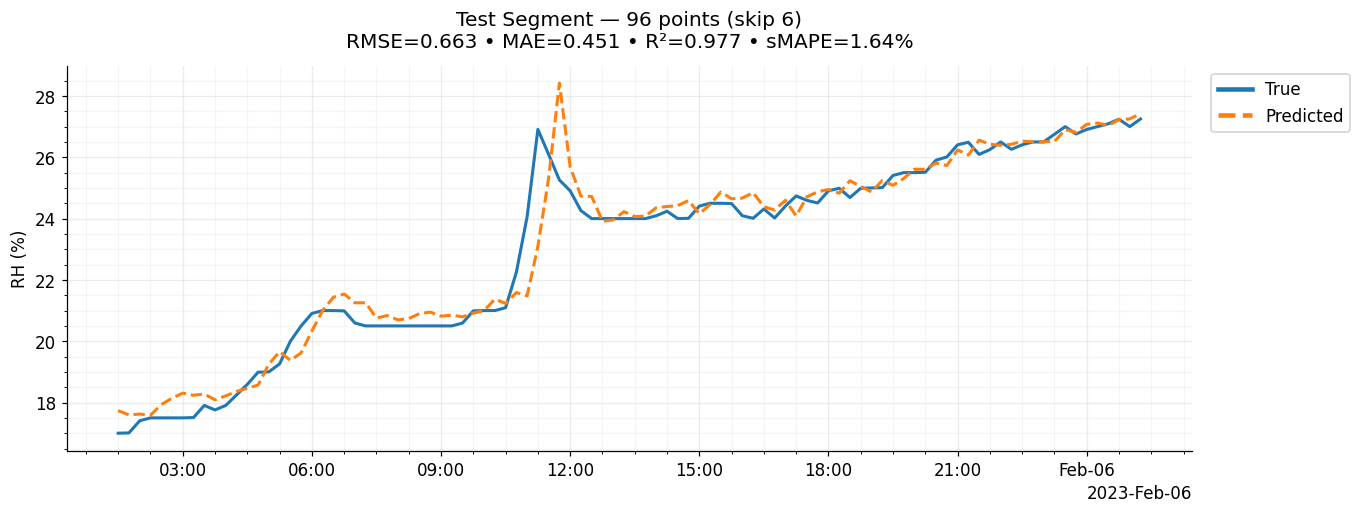

======= House 7 =========
Scaling columns: ['Tout', 'hvac_mode']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17092\500686914.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


[01] Train Loss: 1149.6072 | Val Loss: 133.1283
[02] Train Loss: 612.8738 | Val Loss: 24.7372
[03] Train Loss: 375.8615 | Val Loss: 42.5842
[04] Train Loss: 269.6246 | Val Loss: 8.8228
[05] Train Loss: 165.0959 | Val Loss: 2.6655
[06] Train Loss: 104.8012 | Val Loss: 1.4225
[07] Train Loss: 68.0860 | Val Loss: 1.1889
[08] Train Loss: 45.1682 | Val Loss: 1.4350
[09] Train Loss: 30.6571 | Val Loss: 1.5174
[10] Train Loss: 21.2131 | Val Loss: 1.2756
[11] Train Loss: 15.0002 | Val Loss: 1.0145
[12] Train Loss: 10.8789 | Val Loss: 1.3832
[13] Train Loss: 8.0082 | Val Loss: 1.2479
[14] Train Loss: 6.2679 | Val Loss: 1.1739
[15] Train Loss: 4.9251 | Val Loss: 0.9778
[16] Train Loss: 4.0058 | Val Loss: 1.3564
[17] Train Loss: 3.3469 | Val Loss: 1.4174
[18] Train Loss: 2.8462 | Val Loss: 1.1127
[19] Train Loss: 2.5294 | Val Loss: 1.2053
[20] Train Loss: 2.2779 | Val Loss: 0.9726
[21] Train Loss: 1.9945 | Val Loss: 1.0214
[22] Train Loss: 1.8529 | Val Loss: 0.9526
[23] Train Loss: 1.7905 | Val L

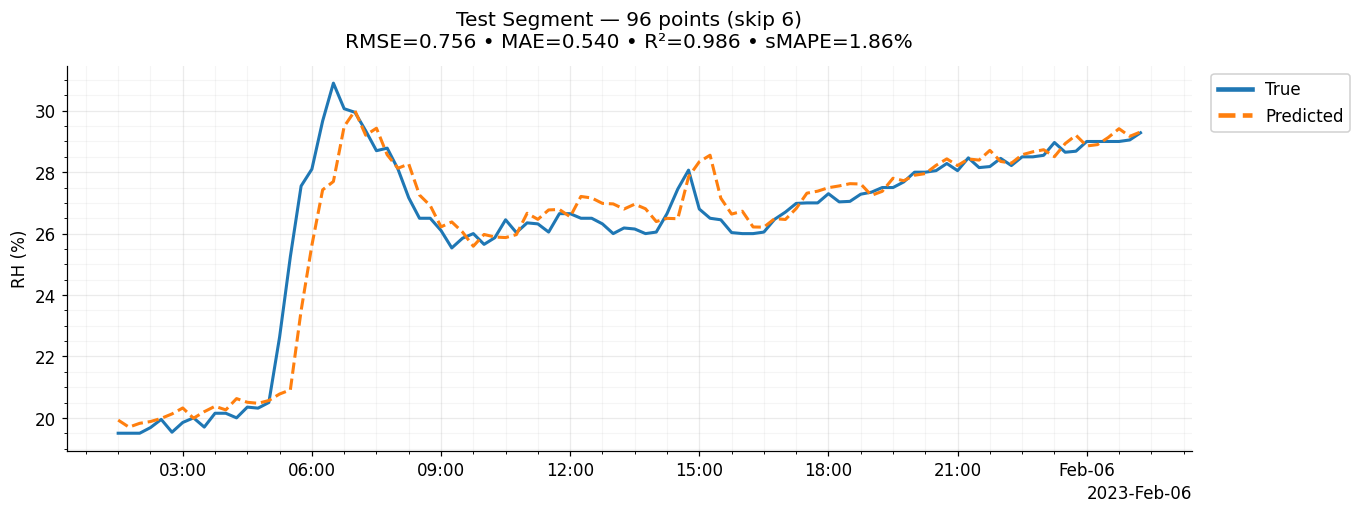

In [3]:
for index,df in enumerate(dfs):
    print(f"======= House {index} =========")

    # df = pd.get_dummies(df, columns=['hvac_mode'], prefix='hvac')
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    rh_input_cols = [
        'RH', 'RH_lag1', 'RH_lag2', 'RH_lag3',
        'Tout', 'hvac_mode', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
    ]

    # for col in ['hvac_0', 'hvac_1', 'hvac_2']:
    #     if col not in df.columns:
    #         df[col] = 0
    df = ensure_columns(df)
    df = df.dropna(subset=["RH_target"])
    df = df.dropna(subset=rh_input_cols)

    # required_cols_rh = rh_input_cols + ['RH_target']
    # nan_mask_rh = df[required_cols_rh].isnull().any(axis=1)
    # df_clean_rh = df[~nan_mask_rh].copy()

    save_dir = f"models/df_{index}"
    save_scaler_dir =  f"models/scalers/df_{index}"
    os.makedirs(save_scaler_dir, exist_ok=True)
    scaler_path = os.path.join(save_scaler_dir, 'scaler_rh.pk1')

    model_rh, scaler_rh = train_lstm_model(
        df,
        input_cols=rh_input_cols,
        target_col='RH_target', window_size=24, batch_size=128, use_scaler=True, epochs=50, hidden_size=64, num_layers=2, lr=0.001, save_dir=save_dir, df_index=index
    )

    # joblib.dump(scaler_rh, scaler_path)
